In [1]:
# if running on colab:
# !git clone https://github.com/laukamkit/capstone_project_GroupA.git
# cd capstone_project_GroupA

In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from NSWData.NSWDataLoader import *
from ModelFiles.ModelPlots import *
nsw_data_loader = NSWDataLoader()

In [4]:
lstm_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_20260412_011518_bilstm_test_results.csv'))
lstm_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_20260412_015622_bilstm_test_results.csv'))
lstm_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'LSTM_results', 'biLSTM_20260412_022959_bilstm_test_results.csv'))
sarimax_results_h48_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'SARIMAX_results', 'sarimax_20260413_150824_test_results.csv'))
sarimax_results_h336_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'SARIMAX_results', 'sarimax_20260413_151716_test_results.csv'))
sarimax_results_h720_df = pd.read_csv(os.path.join(nsw_data_loader.output_dir, 'SARIMAX_results', 'sarimax_20260413_152842_test_results.csv'))

In [5]:
# temporary fix to add horizon column for plotting
sarimax_results_h48_df['horizon'] = [i % 48 for i in range(len(sarimax_results_h48_df))]
sarimax_results_h336_df['horizon'] = [i % 336 for i in range(len(sarimax_results_h336_df))]
sarimax_results_h720_df['horizon'] = [i % 720 for i in range(len(sarimax_results_h720_df))]

In [6]:
results_dict = {
    'LSTM': {
        48: lstm_results_h48_df,
        336: lstm_results_h336_df,
        720: lstm_results_h720_df
    },
    'SARIMAX': {
        48: sarimax_results_h48_df,
        336: sarimax_results_h336_df,
        720: sarimax_results_h720_df
    }
}

In [10]:
CHOSEN_DATE_START = '2020-05-01 00:00:00'  # Set this to a date within the range of your results
HORIZON_TO_PLOT = 336  # Choose from 48, 336, or 720

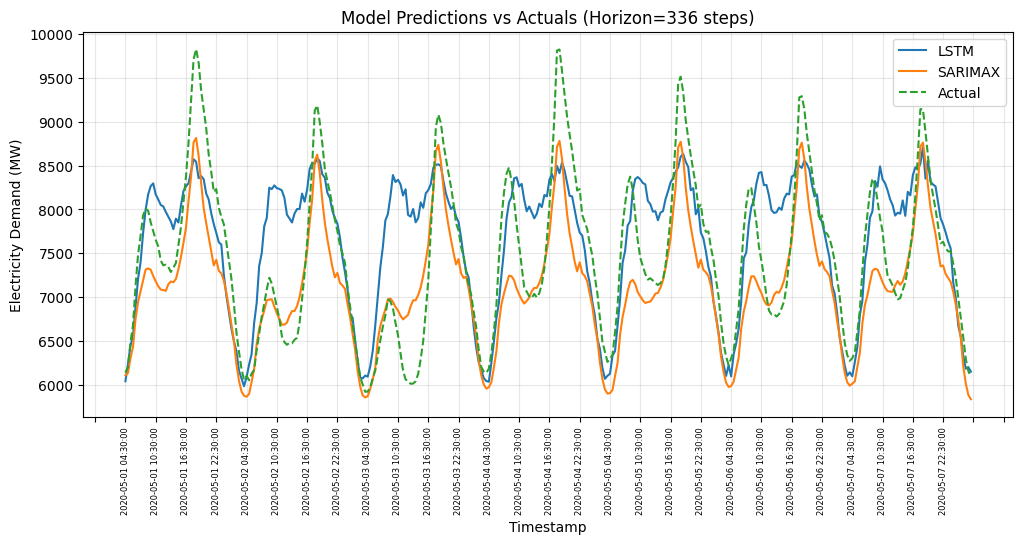

In [11]:
plot_predictions(results_dict, HORIZON_TO_PLOT, CHOSEN_DATE_START)